<a href="https://colab.research.google.com/github/ashwini-mohidekar/neural-networks-basics/blob/main/LeNet_CNN_on_Fashion_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##LeNet

LeNet is one of the earliest and most pioneering Convolutional Neural Networks (CNNs). Developed by Yann LeCun and colleagues at AT&T Bell Labs in 1989, it laid the foundation for modern deep learning and computer vision.

LeNet was designed to recognize small, 28x28-pixel grayscale images of handwritten digits (0-9). Its most well-known version, LeNet-5, became famous for automating character recognition—allowing postal services to read zip codes and ATMs to process handwritten checks.

##Fashion MNIST dataset

Fashion MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 samples and a test set of 10,000 samples.

###LeNet Architecture
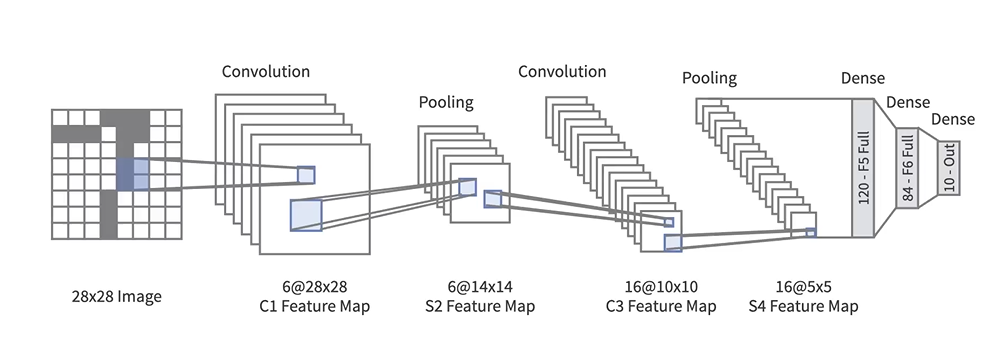


In [6]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [12]:
import torch.nn.functional as F

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

class LeNet(torch.nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # Input(1, 28, 28)
        # First convolution layer: takes 1 input channel (grayscale), produces 6 output feature maps using 5x5 filters
        # padding=2 adds 2 pixels of zeroes around image edges, keeping output size at 28x28.

        self.conv1 = torch.nn.Conv2d(1, 6, 5, padding=2)  # Output: (6, 28, 28)

        # Max pooling layer with 2X2 window and a stride of 2.

        self.pool = torch.nn.MaxPool2d(2, 2)  # Output: (6, 14, 14)

        # Feature maps (lenet has 16 here)
        # Size of the kernel 5x5
        # No padding spatial size reduces form 14x14 to 10x10

        self.conv2 = torch.nn.Conv2d(6, 16, 5)  # Output: (16, 10, 10)

        # After second pooling, size will be (16, 5, 5)

        self.fc1 = torch.nn.Linear(16 * 5 * 5, 120)  # Output: (120, 1)
        self.fc2 = torch.nn.Linear(120, 84)  # Output: (84, 1)
        self.fc3 = torch.nn.Linear(84, 10)  # Output: (10, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)  # Flatten the 3D output (16x5x5) into a 1D vector to feed into the fully connected layers
        # The -1 tells PyTorch to automatically calculate the batch size
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x



model = LeNet().to(device)

In [14]:
# Define a transform to normalize the data
transform = transforms.ToTensor()

# Download and load the training data
train_images = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_images = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_images, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_images, batch_size=64, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

epochs = 30

100%|██████████| 26.4M/26.4M [00:01<00:00, 20.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 314kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.4MB/s]


In [15]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [16]:
model.train()

epochs = epochs

for epoch in range(epochs):
  running_loss = 0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    output = model(images)                # 1. Forward pass
    loss = loss_function(output, labels)  # 2. Calculate Loss
    loss.backward()                       # 3. Backward pass
    optimizer.step()                      # 4. Optimizer step
    running_loss +=loss.item()
  print(f"Epoch {epoch+1} - Training loss: {running_loss/len(train_loader)}")

Epoch 1 - Training loss: 0.6297600969894609
Epoch 2 - Training loss: 0.40480188369306164
Epoch 3 - Training loss: 0.34730393619838557
Epoch 4 - Training loss: 0.31640922761103235
Epoch 5 - Training loss: 0.2956915167507841
Epoch 6 - Training loss: 0.27271624887262835
Epoch 7 - Training loss: 0.25935062494422834
Epoch 8 - Training loss: 0.24660941594635755
Epoch 9 - Training loss: 0.2330036546701371
Epoch 10 - Training loss: 0.22254006909345514
Epoch 11 - Training loss: 0.2132674431336968
Epoch 12 - Training loss: 0.20228178882554396
Epoch 13 - Training loss: 0.19392903322286442
Epoch 14 - Training loss: 0.18460003966525165
Epoch 15 - Training loss: 0.17638644749231175
Epoch 16 - Training loss: 0.1705894971123414
Epoch 17 - Training loss: 0.16386177141402067
Epoch 18 - Training loss: 0.15725196376125186
Epoch 19 - Training loss: 0.1492140040115348
Epoch 20 - Training loss: 0.14365070705204758
Epoch 21 - Training loss: 0.13670544877155885
Epoch 22 - Training loss: 0.13137036315135675
Epo

In [17]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= size
  print(f"Test error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

test(test_loader, model, loss_function)

Test error: 
 Accuracy: 90.3%, Avg loss: 0.380906 

